# Load Data

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu
from scipy.stats import pearsonr, kendalltau
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Probit
from stargazer.stargazer import Stargazer

pd.set_option('display.max_columns', None)

In [11]:
ev = pd.read_excel('../../data/interim/03_pagetimes/evaluator_full_merged.xlsx')

In [48]:
ev[(ev['treat']==0) & (ev['punish_del_good']>0) | (ev['punish_nodel_good']>0)].shape

(52, 135)

# Create Helper Functions and Variables

In [12]:
def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
    return pvalues

In [13]:
ev['female'] = np.nan
ev.loc[ev['Sex']=='Female', 'female'] = 1
ev.loc[ev['Sex']=='Male', 'female'] = 0

#calculate weighted average
ev['wa_difficulty'] = np.nan
for i in range(ev.shape[0]):
    wa = 0
    for j in range(11):
        wa += (ev['difficulty' + str(j)][i]/100)*j
    ev.loc[i, 'wa_difficulty'] = wa
    
#calculate median difficulty
median_variable_list = []
for index, row in ev[['difficulty0', 'difficulty1', 'difficulty2', 'difficulty3', 'difficulty4', 'difficulty5', 'difficulty6', 'difficulty7', 'difficulty8', 'difficulty9', 'difficulty10']].iterrows():
    cumulative_sum = 0
    for column, value in row.iteritems():
        cumulative_sum += value
        if cumulative_sum >= 50:
            median_variable_list.append(column)
            break
ev['med_difficulty'] = pd.Series(median_variable_list)
ev['med_difficulty'] = [int(''.join(filter(str.isdigit, element))) for element in ev['med_difficulty']]

#attention
ev['pass_att2'] = 0
ev.loc[ev['attention']==0.5, 'pass_att2'] = 1

#create variable for people that never punish
ev['never_punish'] = 0
ev.loc[(ev['punish_del_good'] == 0) & (ev['punish_del_bad'] == 0) & (ev['punish_nodel_bad'] == 0) & (ev['punish_nodel_good'] == 0), 'never_punish'] = 1

#punishment differences
ev['bad_good_del'] = ev['punish_del_bad'] - ev['punish_del_good']
ev['bad_good_nodel'] = ev['punish_nodel_bad'] - ev['punish_nodel_good']
ev['nodel_del_good'] = ev['punish_nodel_good'] - ev['punish_del_good']
ev['nodel_del_bad'] = ev['punish_nodel_bad'] - ev['punish_del_bad']

#frequency of punishment variable
for i in ['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']:
    ev[i+'_bin'] = 0
    ev.loc[ev[i]>0, i+'_bin'] = 1

#convert risk task switching point to interval
ev.loc[ev['switching_point']==9999, 'switching_point'] = 110

#for each person calculate how much time they spent on the punishment screen
ev['p_time'] = np.nan
for i in range(ev.shape[0]):
    ev.loc[i, 'p_time'] = (datetime.datetime.utcfromtimestamp(ev['PBE'][i]) - datetime.datetime.utcfromtimestamp(ev['P'][i])).total_seconds()
#one person in pilot had different order
ev.loc[ev['participant.code']=='snj20i5j', 'p_time'] = (datetime.datetime.utcfromtimestamp(ev['Risk'][i]) - datetime.datetime.utcfromtimestamp(ev['P'][i])).total_seconds()

C:\Users\Felix\AppData\Local\Temp\ipykernel_11316\1321252276.py:17: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for column, value in row.iteritems():


# Attention Check

In [49]:
ev[ev['treat']==0]['pass_att2'].value_counts()

1    67
0    13
Name: pass_att2, dtype: int64

In [15]:
ev[['pass_att2', 'treat']].groupby('treat').value_counts()

treat  pass_att2
0      1            67
       0            13
1      1            68
       0            13
dtype: int64

In [16]:
ev['p_time'].describe(percentiles=[.10, .20, .30, .40, .50, .60, .70, .80, .90])

count    161.000000
mean     133.888199
std       77.363831
min       35.000000
10%       60.000000
20%       78.000000
30%       87.000000
40%       99.000000
50%      115.000000
60%      128.000000
70%      155.000000
80%      180.000000
90%      225.000000
max      514.000000
Name: p_time, dtype: float64

In [17]:
#Do subjects for whom the punishmnet is hypothetical take less time? -> No
ev[['p_time', 'treat']].groupby('treat').describe(percentiles=[.10, .20, .30, .40, .50, .60, .70, .80, .90])

p_time                                                               \
       count        mean        std   min   10%   20%   30%    40%    50%   
treat                                                                       
0       80.0  133.937500  79.014875  35.0  57.8  74.8  86.4   94.6  114.5   
1       81.0  133.839506  76.190626  35.0  66.0  79.0  92.0  105.0  115.0   

                                          
         60%    70%    80%    90%    max  
treat                                     
0      142.4  158.0  178.2  226.0  436.0  
1      126.0  143.0  180.0  223.0  514.0

# Difficulty

In [18]:
ev['wa_difficulty'].describe(percentiles=[.10, .20, .30, .40, .50, .60, .70, .80, .90])

count    161.000000
mean       4.323727
std        1.597071
min        0.000000
10%        2.240000
20%        3.240000
30%        3.750000
40%        4.170000
50%        4.500000
60%        4.750000
70%        5.000000
80%        5.320000
90%        5.900000
max       10.000000
Name: wa_difficulty, dtype: float64

In [19]:
ev['med_difficulty'].describe(percentiles=[.10, .20, .30, .40, .50, .60, .70, .80, .90])

count    161.000000
mean       4.062112
std        1.977023
min        0.000000
10%        1.000000
20%        3.000000
30%        3.000000
40%        4.000000
50%        4.000000
60%        5.000000
70%        5.000000
80%        5.000000
90%        6.000000
max       10.000000
Name: med_difficulty, dtype: float64

# Punishment

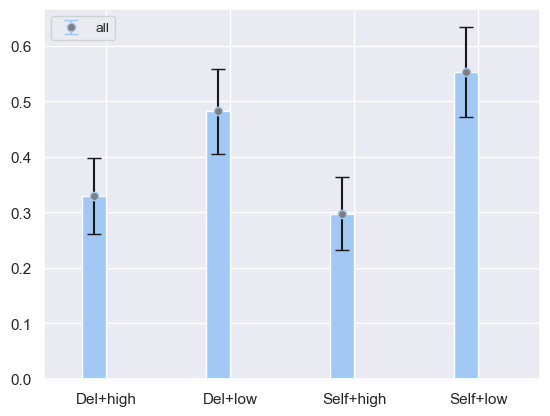

In [20]:
sns.set_theme()
sns.set_palette("pastel")

a=0.1 
t_all = ev[(ev['treat']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos = ev[(ev['treat']==0) & (ev['never_punish']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos_rat = ev[(ev['treat']==0) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T

plt.errorbar([i-a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], fmt='o', capsize=5, label='all', markerfacecolor='grey')
plt.bar([i-a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], capsize=5, width=0.2)

#plt.ylim(0, 1.3)
plt.xlim(0.5, 4.5)
plt.xticks([1, 2, 3, 4], ['Del+high', 'Del+low', 'Self+high', 'Self+low'])
plt.legend(fontsize='small', loc='upper left')
#plt.savefig('punish1.png', dpi=300, bbox_inches='tight')
plt.show()



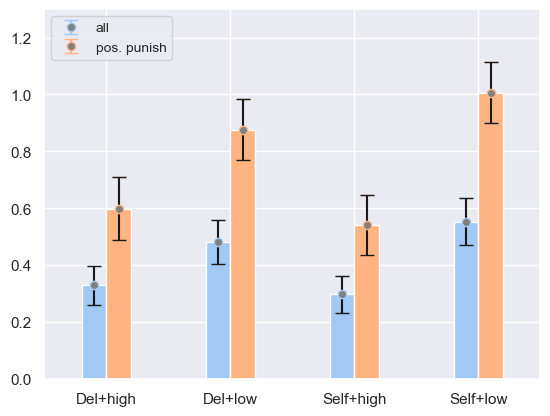

In [21]:
sns.set_theme()
sns.set_palette("pastel")

a=0.1
t_all = ev[(ev['treat']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos = ev[(ev['treat']==0) & (ev['never_punish']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos_rat = ev[(ev['treat']==0) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T

plt.errorbar([i-a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], fmt='o', capsize=5, label='all', markerfacecolor='grey')
plt.bar([i-a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], capsize=5, width=0.2)

plt.errorbar([i+a for i in [1, 2, 3, 4]], t_pos['mean'], yerr=t_pos['sem'], fmt='o', capsize=5, label='pos. punish', markerfacecolor='grey')
plt.bar([i+a for i in [1, 2, 3, 4]], t_pos['mean'], yerr=t_pos['sem'], capsize=5, width=0.2)
                                                             
plt.xlim(0.5, 4.5)
plt.ylim(0, 1.3)
plt.xticks([1, 2, 3, 4], ['Del+high', 'Del+low', 'Self+high', 'Self+low'])
plt.legend(fontsize='small', loc='upper left')
plt.savefig('punish2.png', dpi=300, bbox_inches='tight')
plt.show()


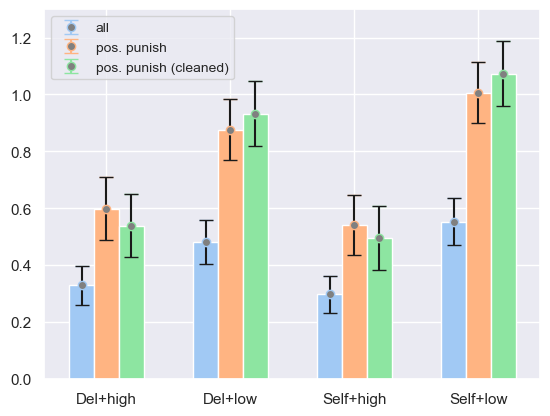

In [22]:
sns.set_theme()
sns.set_palette("pastel")

a=0.2 
t_all = ev[(ev['treat']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos = ev[(ev['treat']==0) & (ev['never_punish']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos_rat = ev[(ev['treat']==0) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T

plt.errorbar([i-a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], fmt='o', capsize=5, label='all', markerfacecolor='grey')
plt.bar([i-a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], capsize=5, width=0.2)

plt.errorbar([1, 2, 3, 4], t_pos['mean'], yerr=t_pos['sem'], fmt='o', capsize=5, label='pos. punish', markerfacecolor='grey')
plt.bar([1, 2, 3, 4], t_pos['mean'], yerr=t_pos['sem'], capsize=5, width=0.2)
                                                             
plt.errorbar([i+a for i in [1, 2, 3, 4]], t_pos_rat['mean'], yerr=t_pos_rat['sem'], fmt='o', capsize=5, label='pos. punish (cleaned)', markerfacecolor='grey')
plt.bar([i+a for i in [1, 2, 3, 4]], t_pos_rat['mean'], yerr=t_pos_rat['sem'], capsize=5, width=0.2)

plt.xlim(0.5, 4.5)
plt.ylim(0, 1.3)
plt.xticks([1, 2, 3, 4], ['Del+high', 'Del+low', 'Self+high', 'Self+low'])
plt.legend(fontsize='small', loc='upper left')
plt.savefig('punish3.png', dpi=300, bbox_inches='tight')
plt.show()


## Punishment treatment only

In [23]:
#full treat=0
ev[ev['treat']==0][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].describe()

,punish_del_good,punish_del_bad,punish_nodel_good,punish_nodel_bad
count,80.000000,80.000000,80.000000,80.000000
mean,0.329375,0.481875,0.297500,0.553125
std,0.612976,0.683219,0.584878,0.727635
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.125000
75%,0.337500,1.000000,0.212500,1.000000
max,2.000000,2.000000,2.000000,2.000000


In [24]:
#treat=0 and only those that punish
ev[(ev['never_punish']==0) & (ev['treat'] == 0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].describe()

,punish_del_good,punish_del_bad,punish_nodel_good,punish_nodel_bad
count,44.000000,44.000000,44.000000,44.000000
mean,0.598864,0.876136,0.540909,1.005682
std,0.724688,0.710019,0.702675,0.712041
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.187500,0.000000,0.287500
50%,0.200000,1.000000,0.200000,1.000000
75%,1.000000,1.387500,1.000000,1.962500
max,2.000000,2.000000,2.000000,2.000000


In [25]:
#treat=0 and only those that punish and pass attention check
ev[(ev['never_punish']==0) & (ev['treat'] == 0) & (ev['pass_att2']==1)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].describe()

,punish_del_good,punish_del_bad,punish_nodel_good,punish_nodel_bad
count,39.000000,39.000000,39.000000,39.000000
mean,0.534615,0.848718,0.533333,0.980769
std,0.678345,0.705102,0.695600,0.693638
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.175000,0.000000,0.400000
50%,0.150000,1.000000,0.200000,1.000000
75%,1.000000,1.300000,1.000000,1.550000
max,2.000000,2.000000,2.000000,2.000000


In [26]:
#treat=0 and only those that punish and not those that punish good more than bad regardless of delegation
ev[(ev['never_punish']==0) & (ev['treat'] == 0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].describe()

,punish_del_good,punish_del_bad,punish_nodel_good,punish_nodel_bad
count,39.000000,39.000000,39.000000,39.000000
mean,0.538462,0.932051,0.494872,1.073077
std,0.695896,0.717496,0.698475,0.716520
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.200000,0.000000,0.400000
50%,0.100000,1.000000,0.100000,1.000000
75%,1.000000,1.500000,1.000000,2.000000
max,2.000000,2.000000,2.000000,2.000000


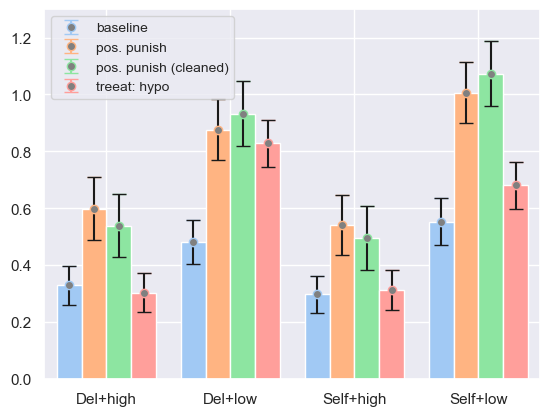

In [27]:
sns.set_theme()
sns.set_palette("pastel")

a=0.2 
t_all = ev[(ev['treat']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos = ev[(ev['treat']==0) & (ev['never_punish']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos_rat = ev[(ev['treat']==0) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
hypo = ev[(ev['treat']==1) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T

plt.errorbar([i-1.5*a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], fmt='o', capsize=5, label='baseline', markerfacecolor='grey')
plt.bar([i-1.5*a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], capsize=5, width=0.2)

plt.errorbar([i-0.5*a for i in [1, 2, 3, 4]], t_pos['mean'], yerr=t_pos['sem'], fmt='o', capsize=5, label='pos. punish', markerfacecolor='grey')
plt.bar([i-0.5*a for i in [1, 2, 3, 4]], t_pos['mean'], yerr=t_pos['sem'], capsize=5, width=0.2)
                                                             
plt.errorbar([i+0.5*a for i in [1, 2, 3, 4]], t_pos_rat['mean'], yerr=t_pos_rat['sem'], fmt='o', capsize=5, label='pos. punish (cleaned)', markerfacecolor='grey')
plt.bar([i+0.5*a for i in [1, 2, 3, 4]], t_pos_rat['mean'], yerr=t_pos_rat['sem'], capsize=5, width=0.2)

plt.errorbar([i+1.5*a for i in [1, 2, 3, 4]], hypo['mean'], yerr=hypo['sem'], fmt='o', capsize=5, label='treeat: hypo', markerfacecolor='grey')
plt.bar([i+1.5*a for i in [1, 2, 3, 4]], hypo['mean'], yerr=hypo['sem'], capsize=5, width=0.2)

plt.xlim(0.5, 4.5)
plt.ylim(0, 1.3)
plt.xticks([1, 2, 3, 4], ['Del+high', 'Del+low', 'Self+high', 'Self+low'])
plt.legend(fontsize='small', loc='upper left')
plt.savefig('punish4.png', dpi=300, bbox_inches='tight')
plt.show()


## Tests for difference

In [28]:
datasets = [ev[(ev['treat']==0)], ev[(ev['treat']==0) & (ev['never_punish']==0)], ev[(ev['treat']==0) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))]]
tests = [ttest_ind, mannwhitneyu]

for d in datasets:
    for t in tests:
        print(t(d['punish_del_bad'], d['punish_nodel_bad']))
        print(t(d['punish_del_good'], d['punish_nodel_good']))

Ttest_indResult(statistic=-0.6384809392974256, pvalue=0.524085049619522)
Ttest_indResult(statistic=0.3365012539261643, pvalue=0.7369394141220029)
MannwhitneyuResult(statistic=3025.0, pvalue=0.5247515209215485)
MannwhitneyuResult(statistic=3227.5, pvalue=0.9117689428424018)
Ttest_indResult(statistic=-0.8545654993144849, pvalue=0.3951660522888686)
Ttest_indResult(statistic=0.38084001663816774, pvalue=0.7042611053543849)
MannwhitneyuResult(statistic=847.0, pvalue=0.3100087695867325)
MannwhitneyuResult(statistic=995.5, pvalue=0.8148160667514545)
Ttest_indResult(statistic=-0.8685427825135177, pvalue=0.3878317602011757)
Ttest_indResult(statistic=0.2760911173610748, pvalue=0.7832274623663851)
MannwhitneyuResult(statistic=660.0, pvalue=0.3113511366300129)
MannwhitneyuResult(statistic=776.5, pvalue=0.8699672452333429)


## Hypothetical Punishment

In [29]:
#full treat=1
ev[ev['treat']==1][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].describe()

,punish_del_good,punish_del_bad,punish_nodel_good,punish_nodel_bad
count,81.000000,81.000000,81.000000,81.000000
mean,0.228395,0.529630,0.222840,0.429012
std,0.445529,0.603364,0.426765,0.554012
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.250000,0.000000,0.100000
75%,0.200000,1.000000,0.100000,0.750000
max,2.000000,2.000000,2.000000,2.000000


In [30]:
#treat=1 and only those that punish
ev[(ev['never_punish']==0) & (ev['treat'] == 1)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].describe()

,punish_del_good,punish_del_bad,punish_nodel_good,punish_nodel_bad
count,52.000000,52.000000,52.000000,52.000000
mean,0.355769,0.825000,0.347115,0.668269
std,0.514939,0.567977,0.491637,0.564300
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.500000,0.000000,0.250000
50%,0.050000,1.000000,0.000000,0.500000
75%,0.662500,1.000000,0.925000,1.000000
max,2.000000,2.000000,2.000000,2.000000


In [31]:
#treat=1 and only those that punish and not those that punish good more than bad regardless of delegation
ev[(ev['never_punish']==0) & (ev['treat'] == 1) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].describe()

,punish_del_good,punish_del_bad,punish_nodel_good,punish_nodel_bad
count,49.000000,49.000000,49.000000,49.000000
mean,0.303061,0.828571,0.312245,0.680612
std,0.477451,0.581127,0.484180,0.579225
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.500000,0.000000,0.250000
50%,0.000000,1.000000,0.000000,0.500000
75%,0.500000,1.000000,0.850000,1.000000
max,2.000000,2.000000,2.000000,2.000000


## Tests for difference in hypothetical treatment

In [32]:
datasets = [ev[(ev['treat']==1)], ev[(ev['treat']==1) & (ev['never_punish']==0)], ev[(ev['treat']==1) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))]]
tests = [ttest_ind, mannwhitneyu]

for d in datasets:
    for t in tests:
        print(t(d['punish_del_bad'], d['punish_nodel_bad']))
        print(t(d['punish_del_good'], d['punish_nodel_good']))

Ttest_indResult(statistic=1.1055059408742207, pvalue=0.2705999703073502)
Ttest_indResult(statistic=0.081044171993932, pvalue=0.9355081112025216)
MannwhitneyuResult(statistic=3560.5, pvalue=0.3271496579105829)
MannwhitneyuResult(statistic=3355.5, pvalue=0.7600388129798893)
Ttest_indResult(statistic=1.4116141425263065, pvalue=0.16110686373395333)
Ttest_indResult(statistic=0.08765220167169044, pvalue=0.9303249636239979)
MannwhitneyuResult(statistic=1588.5, pvalue=0.11771549800173013)
MannwhitneyuResult(statistic=1398.0, pvalue=0.7487020525453509)
Ttest_indResult(statistic=1.262306086758287, pvalue=0.2098966128440049)
Ttest_indResult(statistic=-0.09453889302867835, pvalue=0.924878133999805)
MannwhitneyuResult(statistic=1383.5, pvalue=0.1848716798307305)
MannwhitneyuResult(statistic=1230.0, pvalue=0.8207649524541032)


## Tests for difference between treatments

In [33]:
for i in ['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']:
    print(ttest_ind(ev[ev['treat']==0][i], ev[ev['treat']==1][i]))

Ttest_indResult(statistic=1.196744138739699, pvalue=0.2331876478596611)
Ttest_indResult(statistic=-0.4702364459314925, pvalue=0.6388304576764193)
Ttest_indResult(statistic=0.9260719760245989, pvalue=0.3558120594717864)
Ttest_indResult(statistic=1.2186168124556493, pvalue=0.2247946603871341)


In [34]:
for i in ['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']:
    print(ttest_ind(ev[(ev['treat']==0) & ((ev['never_punish']==0))][i], ev[(ev['treat']==1) & ((ev['never_punish']==0))][i]))

Ttest_indResult(statistic=1.914887770156777, pvalue=0.0585473820757759)
Ttest_indResult(statistic=0.3919702292265198, pvalue=0.6959674718868336)
Ttest_indResult(statistic=1.583416497849837, pvalue=0.1166853948971834)
Ttest_indResult(statistic=2.5893476339720953, pvalue=0.01114378199293274)


## Frequency of punishment

In [35]:
ev[ev['treat']==0][['punish_del_good_bin', 'punish_del_bad_bin', 'punish_nodel_good_bin', 'punish_nodel_bad_bin']].describe()

,punish_del_good_bin,punish_del_bad_bin,punish_nodel_good_bin,punish_nodel_bad_bin
count,80.00000,80.000000,80.00000,80.000000
mean,0.32500,0.487500,0.32500,0.525000
std,0.47133,0.502997,0.47133,0.502525
min,0.00000,0.000000,0.00000,0.000000
25%,0.00000,0.000000,0.00000,0.000000
50%,0.00000,0.000000,0.00000,1.000000
75%,1.00000,1.000000,1.00000,1.000000
max,1.00000,1.000000,1.00000,1.000000


# Punishment Correlations

In [36]:
ev[ev['treat']==0][['bad_good_del', 'bad_good_nodel', 'nodel_del_bad', 'nodel_del_good', 'wa_difficulty', 'med_difficulty', 'switching_point']].corr()

,bad_good_del,bad_good_nodel,nodel_del_bad,nodel_del_good,wa_difficulty,med_difficulty,switching_point
bad_good_del,1.000000,0.617964,-0.174136,0.154377,-0.039289,-0.078263,-0.239874
bad_good_nodel,0.617964,1.000000,0.288717,-0.389157,-0.041125,-0.069364,-0.245454
nodel_del_bad,-0.174136,0.288717,1.000000,0.315651,-0.039950,-0.129354,0.039453
nodel_del_good,0.154377,-0.389157,0.315651,1.000000,-0.025714,-0.113854,0.093971
wa_difficulty,-0.039289,-0.041125,-0.039950,-0.025714,1.000000,0.969893,-0.277367
med_difficulty,-0.078263,-0.069364,-0.129354,-0.113854,0.969893,1.000000,-0.266798
switching_point,-0.239874,-0.245454,0.039453,0.093971,-0.277367,-0.266798,1.000000


In [37]:
ev[ev['treat']==0][['bad_good_del', 'bad_good_nodel', 'nodel_del_bad', 'nodel_del_good', 'trust', 'perception', 'responsibility']].corr()

,bad_good_del,bad_good_nodel,nodel_del_bad,nodel_del_good,trust,perception,responsibility
bad_good_del,1.000000,0.617964,-0.174136,0.154377,0.072612,0.111882,0.024066
bad_good_nodel,0.617964,1.000000,0.288717,-0.389157,0.003290,0.188824,-0.021063
nodel_del_bad,-0.174136,0.288717,1.000000,0.315651,0.107804,0.050269,0.254410
nodel_del_good,0.154377,-0.389157,0.315651,1.000000,0.143903,-0.087311,0.206375
trust,0.072612,0.003290,0.107804,0.143903,1.000000,0.484348,-0.008834
perception,0.111882,0.188824,0.050269,-0.087311,0.484348,1.000000,-0.052633
responsibility,0.024066,-0.021063,0.254410,0.206375,-0.008834,-0.052633,1.000000


In [114]:
ev[ev['treat']==0][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad', 'wa_difficulty', 'med_difficulty', 'switching_point']].corr()

,punish_del_good,punish_del_bad,punish_nodel_good,punish_nodel_bad,wa_difficulty,med_difficulty,switching_point
punish_del_good,1.000000,0.670323,0.709530,0.590739,0.001424,0.042391,-0.012129
punish_del_bad,0.670323,1.000000,0.492467,0.826753,-0.029209,-0.022698,-0.197018
punish_nodel_good,0.709530,0.492467,1.000000,0.563438,-0.018609,-0.044580,0.060751
punish_nodel_bad,0.590739,0.826753,0.563438,1.000000,-0.050343,-0.095516,-0.162360
wa_difficulty,0.001424,-0.029209,-0.018609,-0.050343,1.000000,0.969893,-0.277367
med_difficulty,0.042391,-0.022698,-0.044580,-0.095516,0.969893,1.000000,-0.266798
switching_point,-0.012129,-0.197018,0.060751,-0.162360,-0.277367,-0.266798,1.000000


In [115]:
ev[(ev['treat']==0) & (ev['pass_att2']==1)][['nodel_del_bad', 'nodel_del_good', 'wa_difficulty', 'med_difficulty', 'switching_point']].corr()

,nodel_del_bad,nodel_del_good,wa_difficulty,med_difficulty,switching_point
nodel_del_bad,1.000000,0.529815,-0.037376,-0.149064,0.084363
nodel_del_good,0.529815,1.000000,-0.001231,-0.110920,-0.043231
wa_difficulty,-0.037376,-0.001231,1.000000,0.966518,-0.263972
med_difficulty,-0.149064,-0.110920,0.966518,1.000000,-0.213334
switching_point,0.084363,-0.043231,-0.263972,-0.213334,1.000000


In [129]:
ev[(ev['treat']==0) & (ev['p_time']>120)][['nodel_del_bad', 'nodel_del_good', 'wa_difficulty', 'med_difficulty', 'switching_point']].corr()

,nodel_del_bad,nodel_del_good,wa_difficulty,med_difficulty,switching_point
nodel_del_bad,1.000000,0.645589,0.314595,0.296795,0.020612
nodel_del_good,0.645589,1.000000,0.162532,0.140367,-0.007833
wa_difficulty,0.314595,0.162532,1.000000,0.981874,-0.293068
med_difficulty,0.296795,0.140367,0.981874,1.000000,-0.316003
switching_point,0.020612,-0.007833,-0.293068,-0.316003,1.000000


In [116]:
ev[(ev['pilot']==1)][['nodel_del_bad', 'nodel_del_good', 'wa_difficulty', 'med_difficulty', 'switching_point']].corr()

,nodel_del_bad,nodel_del_good,wa_difficulty,med_difficulty,switching_point
nodel_del_bad,1.000000,0.623189,-0.216924,-0.348026,0.161250
nodel_del_good,0.623189,1.000000,-0.111885,-0.283275,0.031122
wa_difficulty,-0.216924,-0.111885,1.000000,0.970573,-0.363575
med_difficulty,-0.348026,-0.283275,0.970573,1.000000,-0.332267
switching_point,0.161250,0.031122,-0.363575,-0.332267,1.000000


## Order effects

no order effect

In [78]:
ev[['treat', 'eva.id_in_group', 'punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].groupby(['treat', 'eva.id_in_group']).mean()

punish_del_good  punish_del_bad  punish_nodel_good  \
treat eva.id_in_group                                                       
0     1                       0.320732        0.423171           0.247561   
      2                       0.338462        0.543590           0.350000   
1     1                       0.241026        0.580769           0.219231   
      2                       0.216667        0.482143           0.226190   

                       punish_nodel_bad  
treat eva.id_in_group                    
0     1                        0.578049  
      2                        0.526923  
1     1                        0.515385  
      2                        0.348810

# Regressions

In [92]:
#choose dependent variable
dep_vars=['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad', 'bad_good_del', 'bad_good_nodel', 'nodel_del_bad', 'nodel_del_good']

datasets = [ev, ev[ev['treat']==0], ev[ev['never_punish']==0], ev[(ev['treat']==0) & (ev['never_punish']==0)]]

model_summaries = []
for dep in dep_vars:
    #create dictionary with all regression models in the following form "name of model": ["dependent var", [list of regressors]],
    models = {
        "model1": [dep, ['wa_difficulty']],
        "model2": [dep, ['female']],
        "model3": [dep, ['Age']],
        "model4": [dep, ['switching_point']],
    }
    
    list_of_reg_results = []
    for data in datasets:
        for key in models.keys():
            est = sm.OLS(endog=data[models[key][0]], exog=sm.add_constant(data[models[key][1]]), missing='drop').fit()
            list_of_reg_results.append(est)

    model_summary = Stargazer(list_of_reg_results)
    model_summary.custom_columns(['full', 'treat=0', 'positive punish', 'treat=0 and positive punish'], [4, 4, 4, 4])
    model_summary.covariate_order(["const", 'wa_difficulty', 'female', 'Age', 'switching_point'])
    model_summary.show_degrees_of_freedom(False)
    model_summaries.append(model_summary)

model_summaries[0]

In [93]:
model_summaries[1]

In [94]:
model_summaries[2]

In [95]:
model_summaries[3]

In [96]:
model_summaries[4]

In [97]:
model_summaries[5]

In [98]:
model_summaries[6]

In [115]:
model_summaries[7]

In [93]:
est = []

for d in [ev, ev[ev['treat']==0]]:
    param_specs = [
        ['wa_difficulty'],
        ['female'],
        ['Age'],
        ['switching_point']
    ]

    
    for i in param_specs:
        l = i.copy()
        l.append('nodel_del_bad')

        reg = d[l].copy()
        reg = reg.dropna()
        Y = reg['nodel_del_bad']
        X = sm.add_constant(reg[i])
        model = sm.OLS(Y.astype(float),X.astype(float)).fit()
        est.append(model)
stargazer = Stargazer(est)
stargazer.custom_columns(['All observations', 'treat=0'], [4, 4])
stargazer.significant_digits(2)
stargazer.covariate_order(['const', 'wa_difficulty', 'female', 'Age', 'switching_point'])
stargazer.show_degrees_of_freedom(False)

stargazer

In [7]:
ev.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'participant.id_in_session',
       'participant.code', 'app', 'page', 'session.code', 'bad_outcome_eva',
       'good_outcome_eva', 'max_punishment', 'punishment_cost',
       'belief_payment_difficulty', 'risk_payment', 'margin_of_error',
       'eva.id_in_group', 'difficulty0', 'difficulty1', 'difficulty2',
       'difficulty3', 'difficulty4', 'difficulty5', 'difficulty6',
       'difficulty7', 'difficulty8', 'difficulty9', 'difficulty10',
       'error_difficulty', 'punish_del_good', 'punish_del_bad',
       'punish_nodel_good', 'punish_nodel_bad', 'switching_point',
       'random_risk_prob_pick', 'risk_task_payoff', 'research_about',
       'unclear', 'why_punish', 'why_punish_del_less', 'p_id',
       'matched_delegator_id', 'match_outcome', 'match_delegation',
       'attention', 'task_payoff', 'rand_belief', 'belief_difficulty_payoff',
       'punish_payoff', 'final_payoff', 'bonus_payoff', 'Time taken',
       'Total approvals', 'Ethnicity

# Explanations

In [ ]:
frequency of punishment comparison

In [ ]:
relate difficulty and punishments

In [ ]:
graph on how difficult they think it was and how difficult it actually was and how difficult delegators thunk it was